# Deteção de Texto IA vs Humano — Regressão Logística

**Estratégia baseline** com representação TF-IDF e regressão logística em PyTorch.

**Classes alvo:** `Human`, `Google`, `Meta`, `OpenAI`, `Mistral`
(se o dataset não incluir `Mistral`, o notebook usa `Anthropic` como substituto temporário e avisa no output).

**Pipeline:**
```
Texto → Limpeza → TF-IDF → SimpleClassifier (Linear) → CrossEntropyLoss
```

## 1. Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Configuração

In [2]:
DATA_PATH   = "data/dataset-training-final.csv"
TEXT_COL    = "Text"
LABEL_COL   = "Label"
TARGET_CLASSES = ["Human", "Google", "Meta", "OpenAI", "Mistral"]

MAX_WORDS   = 20000           # vocabulário TF-IDF 
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 0.001
VAL_SPLIT   = 0.8             # 80% treino, 20% validação
TEST_SPLIT  = 0.1             # 10% do total reservado para teste
SEED        = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED)

Device: cpu


## 3. Carregamento e Pré-processamento dos Dados

In [3]:
def clean_text(text):
    """Limpeza básica do texto."""
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)       # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)    # mantém apenas letras
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Carregar CSV
df = pd.read_csv(DATA_PATH, sep=";")

available_labels = set(df[LABEL_COL].unique().tolist())
if "Mistral" not in available_labels and "Anthropic" in available_labels:
    print("[Aviso] Classe 'Mistral' não encontrada no dataset atual. Usando 'Anthropic' como substituta temporária.")
    active_classes = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
else:
    active_classes = [c for c in TARGET_CLASSES if c in available_labels]

N_CLASSES = len(active_classes)
df = df[df[LABEL_COL].isin(active_classes)].copy()
print(f"Dataset shape: {df.shape}")
print(f"\nDistribuição de classes:")
print(df[LABEL_COL].value_counts())

# Limpeza do texto
df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

# Codificar labels em inteiros (0..N-1)
le = LabelEncoder()
le.fit(active_classes)   # garante ordem consistente
df["label_enc"] = le.transform(df[LABEL_COL])

print(f"\nMapeamento de classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
df.head(3)

[Aviso] Classe 'Mistral' não encontrada no dataset atual. Usando 'Anthropic' como substituta temporária.
Dataset shape: (21633, 3)

Distribuição de classes:
Label
Google       5300
OpenAI       5300
Human        5300
Anthropic    4733
Meta         1000
Name: count, dtype: int64

Mapeamento de classes: {np.str_('Anthropic'): np.int64(0), np.str_('Google'): np.int64(1), np.str_('Human'): np.int64(2), np.str_('Meta'): np.int64(3), np.str_('OpenAI'): np.int64(4)}


,ID,Text,Label,clean_text,label_enc
0,D1-1,"The human heart beats approximately 100,000 ti...",Anthropic,the human heart beats approximately times per day,0
1,D1-2,The Milky Way galaxy contains an estimated 100...,Anthropic,the milky way galaxy contains an estimated bil...,0
2,D1-3,Photosynthesis is the process by which plants ...,Anthropic,photosynthesis is the process by which plants ...,0


## 4. Divisão Treino / Validação / Teste

In [4]:
from sklearn.model_selection import train_test_split

texts = df["clean_text"].tolist()
labels = df["label_enc"].tolist()

# Separar teste primeiro
texts_trainval, texts_test, labels_trainval, labels_test = train_test_split(
    texts, labels, test_size=TEST_SPLIT, random_state=SEED, stratify=labels
)

# Separar treino / validação
val_ratio = 1 - VAL_SPLIT          # fracção do trainval para validação
texts_train, texts_val, labels_train, labels_val = train_test_split(
    texts_trainval, labels_trainval, test_size=val_ratio, random_state=SEED, stratify=labels_trainval
)

print(f"Treino:    {len(texts_train):>5} exemplos")
print(f"Validação: {len(texts_val):>5} exemplos")
print(f"Teste:     {len(texts_test):>5} exemplos")

Treino:    15575 exemplos
Validação:  3894 exemplos
Teste:      2164 exemplos


## 5. Representação TF-IDF e Dataset PyTorch

In [5]:
# Fit do vectorizador apenas nos dados de treino (evita data leakage)
vectorizer = TfidfVectorizer(
    max_features=MAX_WORDS,
    ngram_range=(1, 2),       # unigramas + bigramas
    stop_words="english",
    min_df=2
)
X_train = vectorizer.fit_transform(texts_train).toarray()
X_val   = vectorizer.transform(texts_val).toarray()
X_test  = vectorizer.transform(texts_test).toarray()

print(f"Shape TF-IDF treino: {X_train.shape}")

Shape TF-IDF treino: (15575, 20000)


In [6]:
class TextDataset(Dataset):
    """Dataset genérico para features pré-computadas + labels inteiros (multiclasse)"""
    def __init__(self, X, labels):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)   # CrossEntropyLoss precisa de long

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TextDataset(X_train, labels_train)
val_dataset   = TextDataset(X_val,   labels_val)
test_dataset  = TextDataset(X_test,  labels_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

## 6. Modelo — Regressão Logística (SimpleClassifier)

In [7]:
class SimpleClassifier(nn.Module):
    """
    Regressão Logística Multiclasse.
    Uma única camada linear: input_dim → nclasses.
    (equivalente ao SimpleClassifier do imdb-torch-full.py, adaptado para multiclasse)
    """
    def __init__(self, input_dim, nclasses):
        super().__init__()
        self.linear = nn.Linear(input_dim, nclasses)

    def forward(self, x):
        return self.linear(x)   # logits — CrossEntropyLoss aplica softmax internamente


input_dim = X_train.shape[1]
model = SimpleClassifier(input_dim, N_CLASSES).to(device)
print(model)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters()):,}")

SimpleClassifier(
  (linear): Linear(in_features=20000, out_features=5, bias=True)
)

Parâmetros treináveis: 100,005


## 7. Treino e Avaliação

In [8]:
def evaluate(model, loader, criterion):
    """Calcula loss e accuracy num DataLoader — idêntico ao imdb-torch-full.py, adaptado para multiclasse"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)                          # logits: (B, nclasses)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)               # classe com maior logit
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total


def train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, verbose=True):
    """Loop de treino — baseado no train() do imdb-torch-full.py"""
    criterion = nn.CrossEntropyLoss()                   # multiclasse (substitui BCELoss)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader,   criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose and epoch % 5 == 0:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return history

In [9]:
history = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 05/30 | Train Loss: 1.1168 Acc: 0.7938 | Val Loss: 1.2291 Acc: 0.5842
Epoch 10/30 | Train Loss: 0.8781 Acc: 0.8618 | Val Loss: 1.0750 Acc: 0.6243
Epoch 15/30 | Train Loss: 0.7193 Acc: 0.8957 | Val Loss: 0.9804 Acc: 0.6479
Epoch 20/30 | Train Loss: 0.6048 Acc: 0.9151 | Val Loss: 0.9181 Acc: 0.6572
Epoch 25/30 | Train Loss: 0.5182 Acc: 0.9317 | Val Loss: 0.8754 Acc: 0.6608
Epoch 30/30 | Train Loss: 0.4498 Acc: 0.9427 | Val Loss: 0.8453 Acc: 0.6644


## 8. Curvas de Aprendizagem

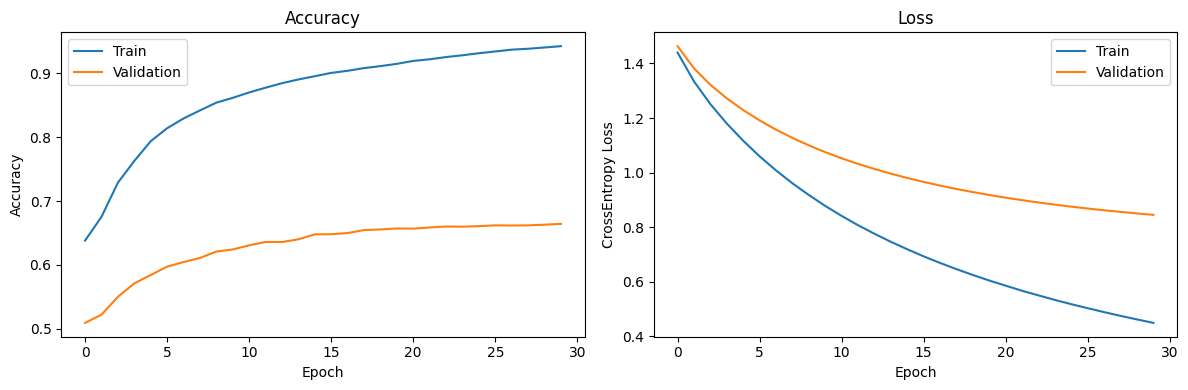

In [10]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_acc"], label="Train")
    axes[0].plot(history["val_acc"],   label="Validation")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history["train_loss"], label="Train")
    axes[1].plot(history["val_loss"],   label="Validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("CrossEntropy Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## 9. Avaliação no Conjunto de Teste

In [11]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.8195
Test Accuracy: 0.6945


In [12]:
# Classification report por classe
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_class_indices = list(range(len(le.classes_)))
print(classification_report(
    all_labels,
    all_preds,
    labels=all_class_indices,
    target_names=le.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

   Anthropic       0.72      0.62      0.67       474
      Google       0.62      0.63      0.62       530
       Human       0.76      0.84      0.79       530
        Meta       0.91      0.89      0.90       100
      OpenAI       0.64      0.65      0.65       530

    accuracy                           0.69      2164
   macro avg       0.73      0.72      0.73      2164
weighted avg       0.69      0.69      0.69      2164



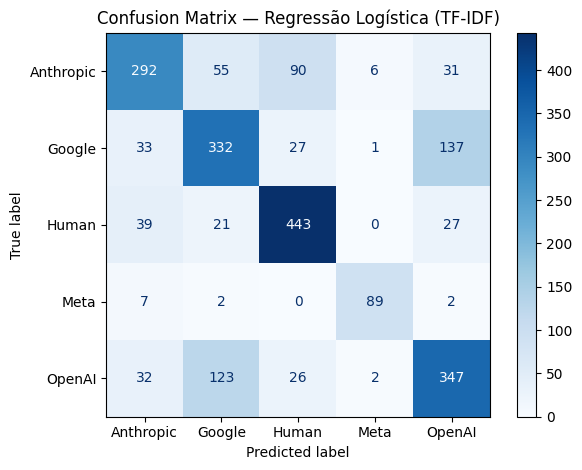

In [13]:
# Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Regressão Logística (TF-IDF)")
plt.tight_layout()
plt.show()

## 10. Inferência — Classificar Novo Texto

In [14]:
def predict_text(text, model, vectorizer, label_encoder, device):
    """Classifica um texto novo e devolve a classe prevista e as probabilidades."""
    model.eval()
    cleaned = clean_text(text)
    x = vectorizer.transform([cleaned]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(x_tensor)              # (1, nclasses)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    print(f"Classe prevista: {label_encoder.classes_[pred]}")
    print("Probabilidades:")
    for cls, p in zip(label_encoder.classes_, probs):
        print(f"  {cls:12s}: {p:.4f}")
    return label_encoder.classes_[pred], probs


# Exemplo
sample = "The advancements in large language models have been remarkable over the past few years."
predict_text(sample, model, vectorizer, le, device)

Classe prevista: Human
Probabilidades:
  Anthropic   : 0.2360
  Google      : 0.2293
  Human       : 0.3948
  Meta        : 0.0098
  OpenAI      : 0.1301


(np.str_('Human'),
 array([0.23603646, 0.22930272, 0.3947746 , 0.00983454, 0.13005163],
       dtype=float32))